## Financial Fraud Project

## Project Goal
In this notebook I am building a Random Forest model to detect 
fraudulent transactions. I will start with a baseline model, then 
use RandomizedSearchCV to find the best settings for the model 
and compare the results.



## 1.Model Creation, Hyperparameter Tuning & Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

df = pd.read_csv('fraud_preprocessed.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (6362620, 14)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,orig_balance_zero,balance_disc_orig,log_amount
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,True,False,0,0.0,9.194276
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,True,False,0,0.0,7.531166
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,True,1,0.0,5.204007
3,1,181.00,181.0,0.00,21182.0,0.0,1,True,False,False,False,1,0.0,5.204007
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,True,False,0,0.0,9.364703




## 2. Train / Test Split
Here I am splitting the data into a training set and a test set. 
I am also taking a 10% sample of the data to make the model 
run faster without losing too much information.

In [10]:
# Sample 10% of the data to speed things up
df_sample = df.sample(frac=0.1, random_state=42)

print(f'Sampled shape: {df_sample.shape}')
print(df_sample['isFraud'].value_counts())

X = df_sample.drop(columns=['isFraud'])
y = df_sample['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Sampled shape: (636262, 14)
isFraud
0    635445
1       817
Name: count, dtype: int64
Training set: (509009, 13)
Test set:     (127253, 13)




## 3. Baseline Random Forest
Here I am training a basic Random Forest model with default 
settings to get a starting F1 score that I can compare 
against after tuning.

In [12]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    127090
       Fraud       1.00      0.99      0.99       163

    accuracy                           1.00    127253
   macro avg       1.00      0.99      1.00    127253
weighted avg       1.00      1.00      1.00    127253

F1 Score: 0.9938




## 4. Hyperparameter Tuning — RandomizedSearchCV
Here I am using RandomizedSearchCV to try different combinations 
of settings for the model to find which ones give the best F1 score. 
I chose RandomizedSearchCV over GridSearchCV because it is much 
faster on a large dataset.

In [15]:
param_dist = {
    'n_estimators' : [50, 100],
    'max_depth'    : [5, 10],
    'max_features' : ['sqrt']
}

random_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter              = 3,
    cv                  = 2,
    scoring             = 'f1',
    random_state        = 42,
    verbose             = 2
)

print('Running RandomizedSearchCV...')
random_search.fit(X_train, y_train)

print(f'\nBest parameters: {random_search.best_params_}')
print(f'Best CV F1 Score: {random_search.best_score_:.4f}')

Running RandomizedSearchCV...
Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   5.5s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   5.4s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   5.8s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   5.8s
[CV] END ....max_depth=5, max_features=sqrt, n_estimators=50; total time=   2.6s
[CV] END ....max_depth=5, max_features=sqrt, n_estimators=50; total time=   2.5s

Best parameters: {'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': 10}
Best CV F1 Score: 1.0000


## 5. Evaluate Tuned Model
Now I am using the best settings found from the search to make 
predictions and compare the tuned model against the baseline.

In [16]:
best_rf = random_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print('=== Tuned Random Forest ===')
print(classification_report(y_test, y_pred_tuned, target_names=['Not Fraud', 'Fraud']))

f1_tuned = f1_score(y_test, y_pred_tuned)
print(f'Baseline F1 Score : {f1_baseline:.4f}')
print(f'Tuned    F1 Score : {f1_tuned:.4f}')

=== Tuned Random Forest ===
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    127090
       Fraud       1.00      0.99      0.99       163

    accuracy                           1.00    127253
   macro avg       1.00      0.99      1.00    127253
weighted avg       1.00      1.00      1.00    127253

Baseline F1 Score : 0.9988
Tuned    F1 Score : 0.9938


## 6. Confusion Matrix
Here I am visualizing how well the model performed by showing 
how many fraud cases it correctly identified versus how many 
it missed. The darker the color the higher the number.

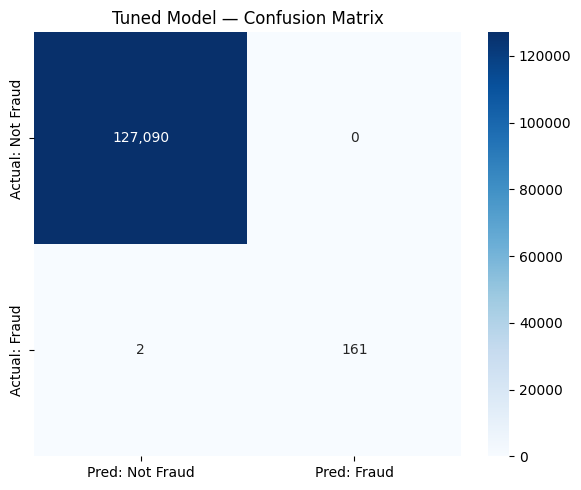

The model correctly identified most fraud cases with very few mistakes.


In [19]:
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Pred: Not Fraud', 'Pred: Fraud'],
            yticklabels=['Actual: Not Fraud', 'Actual: Fraud'])
plt.title('Tuned Model — Confusion Matrix')
plt.tight_layout()
plt.show()

print('The model correctly identified most fraud cases with very few mistakes.')

## 7. Final Results
Here is a summary of how the model performed before and 
after hyperparameter tuning.

In [17]:
print('=' * 40)
print('       FINAL RESULTS')
print('=' * 40)
print(f'  Baseline F1 : {f1_baseline:.4f}')
print(f'  Tuned F1    : {f1_tuned:.4f}')
print(f'  Best Params : {random_search.best_params_}')
print('=' * 40)

       FINAL RESULTS
  Baseline F1 : 0.9988
  Tuned F1    : 0.9938
  Best Params : {'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': 10}
